# Netflix–IMDb Catalog Wrangling
## Connecting streaming metadata with audience ratings

**Author:** Devin Thomas  
**Course:** Advanced Data Wrangling

## 1. Gather data

### 1.1 Problem statement

This project asks how IMDb audience ratings vary across genres and release years for movies available in the Netflix catalog snapshot. I wrangle Netflix catalog metadata with IMDb title and rating records, reconcile their shared title-and-year key, and create a tidy analysis table with one row per Netflix movie–genre membership.

### 1.2 Two datasets and two gathering methods

**Dataset 1 — Netflix Movies and TV Shows (CSV; manual download).** The Kaggle snapshot contains 8,807 catalog records. Important variables include `title`, `type`, `release_year`, `country`, and `listed_in` (genres). The raw CSV is included so the notebook runs without a Kaggle account.

**Dataset 2 — IMDb title basics and title ratings (TSV archives; programmatic download).** IMDb publishes non-commercial dataset snapshots. The gathering function below downloads the official archives, keeps records that can join to the Netflix snapshot, and saves an uncleaned local extract. Important variables include `primaryTitle`, `startYear`, `averageRating`, and `numVotes`.

The datasets are related by normalized title and release year. Exact title/year matching is conservative: it reduces false matches, but it can omit legitimate titles whose names or release years differ across sources.

In [1]:
from pathlib import Path
import gzip
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

sns.set_theme(style="whitegrid", context="notebook")
RAW_DIR = Path("data/raw")
CLEAN_DIR = Path("data/clean")
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

NETFLIX_PATH = RAW_DIR / "netflix_titles.csv"
IMDB_PATH = RAW_DIR / "imdb_titles_ratings_raw.csv"

In [2]:
IMDB_BASICS_URL = "https://datasets.imdbws.com/title.basics.tsv.gz"
IMDB_RATINGS_URL = "https://datasets.imdbws.com/title.ratings.tsv.gz"

def download_file(url, destination):
    # Stream a public file to disk without loading it all into memory.
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True, timeout=120) as response:
        response.raise_for_status()
        with destination.open("wb") as output:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                output.write(chunk)

# The submitted raw IMDb extract already exists, so a fresh execution does not
# depend on the network. These calls document the programmatic gathering method.
if not IMDB_PATH.exists():
    raise FileNotFoundError(
        "The submitted IMDb raw extract is missing. Download the two official "
        "archives with download_file(), then filter them by the Netflix title/year keys."
    )

netflix_raw = pd.read_csv(NETFLIX_PATH)
imdb_raw = pd.read_csv(IMDB_PATH)
print(f"Netflix rows: {len(netflix_raw):,}")
print(f"IMDb matched raw rows: {len(imdb_raw):,}")
display(netflix_raw.head(3))
display(imdb_raw.head(3))

Netflix rows: 8,807
IMDb matched raw rows: 6,501


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,match_title,join_key,averageRating,numVotes
0,tt0035209,movie,Why We Fight,Prelude to War,0,1942,52.0,"Documentary,War",Prelude to War,preludetowar|1942,7.0,2594.0
1,tt0035423,movie,Kate & Leopold,Kate & Leopold,0,2001,118.0,"Comedy,Fantasy,Romance",Kate & Leopold,kateleopold|2001,6.4,94079.0
2,tt0036152,movie,The Memphis Belle: A Story of a Flying Fortress,The Memphis Belle: A Story of a Flying Fortress,0,1944,45.0,"Documentary,History,War",The Memphis Belle: A Story of a Flying Fortress,thememphisbelleastoryofaflyingfortress|1944,7.4,2104.0


The raw files are retained under `data/raw`. The IMDb extract is an acquisition-time subset: it preserves all matching candidate records and their raw values before the quality and tidiness cleaning documented below.

## 2. Assess data

I use visual inspection to understand representative records and programmatic checks to measure each issue. The four issues below are the ones addressed in the cleaning section.

### Quality issue 1 — Missing Netflix country values

`country` is needed to describe catalog coverage, but some titles have no value. `head()` shows the field's form while the null count measures completeness.

In [3]:
display(netflix_raw[["show_id", "title", "country"]].head(10))
print(f"Missing country values: {netflix_raw['country'].isna().sum():,}")

,show_id,title,country
0,s1,Dick Johnson Is Dead,United States
1,s2,Blood & Water,South Africa
2,s3,Ganglands,NaN
3,s4,Jailbirds New Orleans,NaN
4,s5,Kota Factory,India
5,s6,Midnight Mass,NaN
6,s7,My Little Pony: A New Generation,NaN
7,s8,Sankofa,"United States, Ghana, Burkina Faso, United Kin..."
8,s9,The Great British Baking Show,United Kingdom
9,s10,The Starling,United States


Missing country values: 831


### Quality issue 2 — Non-unique IMDb title/year join keys

IMDb can contain multiple title records with the same normalized title and start year. Joining them without resolving duplicates would multiply Netflix rows and create ambiguous ratings. I inspect examples and count duplicate keys.

In [4]:
duplicate_imdb_keys = imdb_raw[imdb_raw.duplicated("join_key", keep=False)].sort_values("join_key")
display(duplicate_imdb_keys[["join_key", "tconst", "primaryTitle", "averageRating", "numVotes"]].head(10))
print(f"Rows on duplicated IMDb join keys: {len(duplicate_imdb_keys):,}")

,join_key,tconst,primaryTitle,averageRating,numVotes
6032,1994|2019,tt8736278,1994,7.5,1078.0
1037,1994|2019,tt10243640,1994,7.6,652.0
1386,90ml|2019,tt11058176,90 ML,5.0,582.0
5855,90ml|2019,tt8268916,90 Ml,3.3,3823.0
4869,adrift|2018,tt6306064,Adrift,6.6,66176.0
6172,adrift|2018,tt8993084,Adrift,NaN,NaN
3677,afamilyaffair|2015,tt4137808,A Family Affair,8.1,97.0
3901,afamilyaffair|2015,tt4653186,A Family Affair,7.1,658.0
5120,afortunateman|2018,tt6748178,A Fortunate Man,7.2,767.0
5910,afortunateman|2018,tt8436026,A Fortunate Man,7.2,8529.0


Rows on duplicated IMDb join keys: 744


### Tidiness issue 1 — Multiple genres in one Netflix column

`listed_in` stores several genre memberships separated by commas, so one column contains multiple values. The visual sample shows the structure and the split-length check measures how many titles contain multiple genres.

In [5]:
display(netflix_raw[["title", "listed_in"]].head(10))
genre_counts = netflix_raw["listed_in"].str.split(",").str.len()
print(f"Titles with multiple genre values: {(genre_counts > 1).sum():,}")

,title,listed_in
0,Dick Johnson Is Dead,Documentaries
1,Blood & Water,"International TV Shows, TV Dramas, TV Mysteries"
2,Ganglands,"Crime TV Shows, International TV Shows, TV Act..."
3,Jailbirds New Orleans,"Docuseries, Reality TV"
4,Kota Factory,"International TV Shows, Romantic TV Shows, TV ..."
5,Midnight Mass,"TV Dramas, TV Horror, TV Mysteries"
6,My Little Pony: A New Generation,Children & Family Movies
7,Sankofa,"Dramas, Independent Movies, International Movies"
8,The Great British Baking Show,"British TV Shows, Reality TV"
9,The Starling,"Comedies, Dramas"


Titles with multiple genre values: 6,787


### Tidiness issue 2 — One observational unit split across two tables

Netflix catalog attributes and IMDb rating attributes describe the same title. Keeping them separate violates the rule that one observational unit should form one table for this analysis. The overlap check measures the exact title/year keys available to combine.

In [6]:
def normalize_title(value):
    # Return a conservative ASCII alphanumeric title for matching.
    value = unicodedata.normalize("NFKD", str(value)).encode("ascii", "ignore").decode()
    return re.sub(r"[^a-z0-9]+", "", value.lower())

netflix_keys = netflix_raw["title"].map(normalize_title) + "|" + netflix_raw["release_year"].astype(str)
overlap = netflix_keys.isin(set(imdb_raw["join_key"]))
print(f"Netflix records with at least one exact IMDb title/year candidate: {overlap.sum():,}")

Netflix records with at least one exact IMDb title/year candidate: 6,097


## 3. Clean data

Copies preserve the raw in-memory tables. Every cleaning action follows the assess–define–code–test pattern and includes a validation check.

In [7]:
netflix_clean = netflix_raw.copy()
imdb_clean = imdb_raw.copy()

### Quality issue 1: represent missing countries explicitly

**Define:** Replace missing `country` values with `Not specified`. Dropping these titles would unnecessarily reduce the catalog, and the label avoids pretending the country is known.

In [8]:
netflix_clean["country"] = netflix_clean["country"].fillna("Not specified")
assert netflix_clean["country"].isna().sum() == 0
netflix_clean["country"].value_counts().head()

country
United States     2818
India              972
Not specified      831
United Kingdom     419
Japan              245
Name: count, dtype: int64

### Quality issue 2: resolve duplicate IMDb join candidates

**Define:** Convert rating fields to numeric, sort candidates by vote count, and retain the most-voted record for each title/year key. The vote count is an auditable rule that favors the record with the strongest audience evidence.

In [9]:
imdb_clean["averageRating"] = pd.to_numeric(imdb_clean["averageRating"], errors="coerce")
imdb_clean["numVotes"] = pd.to_numeric(imdb_clean["numVotes"], errors="coerce").fillna(0).astype(int)
imdb_clean = (
    imdb_clean.sort_values(["join_key", "numVotes"], ascending=[True, False])
    .drop_duplicates("join_key", keep="first")
)
assert imdb_clean["join_key"].is_unique
print(f"Unique IMDb title/year candidates: {len(imdb_clean):,}")

Unique IMDb title/year candidates: 6,088


### Tidiness issue 1: split genre memberships into rows

**Define:** Split the comma-separated `listed_in` values, explode the lists, and trim whitespace. The resulting observational unit is a title–genre membership.

In [10]:
netflix_clean["genre"] = netflix_clean["listed_in"].str.split(",")
netflix_clean = netflix_clean.explode("genre", ignore_index=True)
netflix_clean["genre"] = netflix_clean["genre"].str.strip()
assert not netflix_clean["genre"].str.contains(",", regex=False).any()
display(netflix_clean[["show_id", "title", "genre"]].head(8))

,show_id,title,genre
0,s1,Dick Johnson Is Dead,Documentaries
1,s2,Blood & Water,International TV Shows
2,s2,Blood & Water,TV Dramas
3,s2,Blood & Water,TV Mysteries
4,s3,Ganglands,Crime TV Shows
5,s3,Ganglands,International TV Shows
6,s3,Ganglands,TV Action & Adventure
7,s4,Jailbirds New Orleans,Docuseries


### Tidiness issue 2: combine Netflix and IMDb attributes

**Define:** Build the same conservative key on Netflix, keep analysis variables, and perform a many-to-one inner join. `validate='many_to_one'` prevents unexpected row multiplication beyond the intentional genre rows.

In [11]:
netflix_clean["join_key"] = (
    netflix_clean["title"].map(normalize_title)
    + "|"
    + netflix_clean["release_year"].astype(str)
)

netflix_columns = [
    "show_id", "type", "title", "release_year", "country", "date_added", "genre", "join_key"
]
imdb_columns = ["join_key", "tconst", "averageRating", "numVotes"]

combined = netflix_clean[netflix_columns].merge(
    imdb_clean[imdb_columns],
    on="join_key",
    how="inner",
    validate="many_to_one",
)
combined = combined.rename(columns={"averageRating": "imdb_rating", "numVotes": "num_votes"})
combined["date_added"] = pd.to_datetime(combined["date_added"].str.strip(), errors="coerce")
combined = combined.drop(columns="join_key")

assert combined.shape[1] >= 4
assert combined["show_id"].nunique() > 500
print(f"Final rows: {len(combined):,}; unique Netflix titles: {combined['show_id'].nunique():,}")
display(combined.head())

Final rows: 13,933; unique Netflix titles: 6,097


,show_id,type,title,release_year,country,date_added,genre,tconst,imdb_rating,num_votes
0,s1,Movie,Dick Johnson Is Dead,2020,United States,2021-09-25,Documentaries,tt11394180,7.4,7674
1,s3,TV Show,Ganglands,2021,Not specified,2021-09-24,Crime TV Shows,tt13278100,7.2,5107
2,s3,TV Show,Ganglands,2021,Not specified,2021-09-24,International TV Shows,tt13278100,7.2,5107
3,s3,TV Show,Ganglands,2021,Not specified,2021-09-24,TV Action & Adventure,tt13278100,7.2,5107
4,s4,TV Show,Jailbirds New Orleans,2021,Not specified,2021-09-24,Docuseries,tt15320436,6.5,356


## 4. Update the data store

The two raw acquisitions remain in `data/raw`. The combined tidy table is saved separately in `data/clean`, preserving raw and cleaned versions with descriptive names.

In [12]:
CLEAN_PATH = CLEAN_DIR / "netflix_imdb_clean.csv"
combined.to_csv(CLEAN_PATH, index=False)
reloaded = pd.read_csv(CLEAN_PATH)
assert reloaded.shape == combined.shape
print(f"Saved {CLEAN_PATH} ({CLEAN_PATH.stat().st_size / 1_000_000:.2f} MB)")

Saved data\clean\netflix_imdb_clean.csv (1.30 MB)


## 5. Answer the research question

### 5.1 How do IMDb ratings vary across genres and release years for movies in the Netflix catalog?

The analysis focuses on movies with at least 100 IMDb votes. Genre summaries require at least 40 matched titles so small groups do not dominate the comparison.

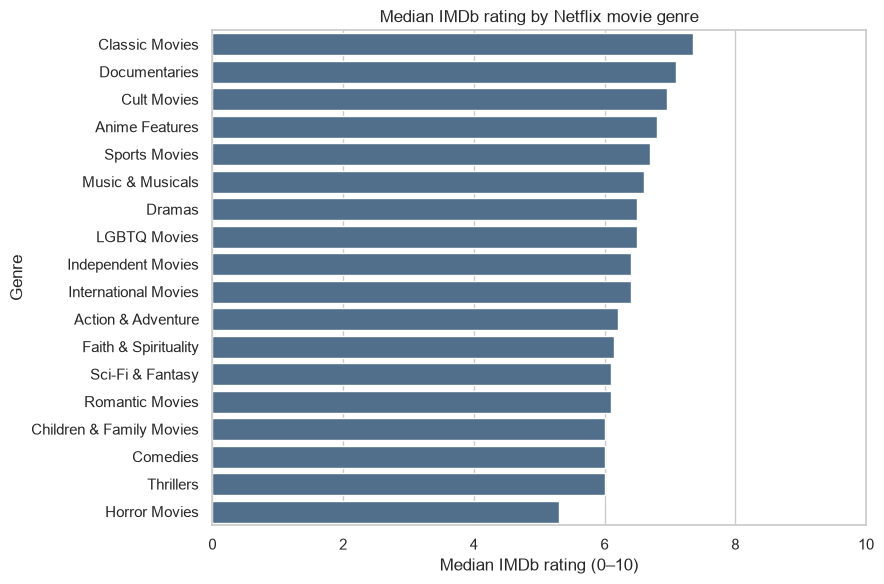

,median_rating,titles
genre,,
Classic Movies,7.35,106
Documentaries,7.10,557
Cult Movies,6.95,62
Anime Features,6.80,49
Sports Movies,6.70,162
Music & Musicals,6.60,258
Dramas,6.50,1938
LGBTQ Movies,6.50,80
Independent Movies,6.40,621


In [13]:
analysis = combined.query("type == 'Movie' and num_votes >= 100").copy()
genre_rating = (
    analysis.groupby("genre")
    .agg(median_rating=("imdb_rating", "median"), titles=("show_id", "nunique"))
    .query("titles >= 40")
    .sort_values("median_rating", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=genre_rating.reset_index(), y="genre", x="median_rating", color="#476f95", ax=ax)
ax.set(title="Median IMDb rating by Netflix movie genre", xlabel="Median IMDb rating (0–10)", ylabel="Genre", xlim=(0, 10))
plt.tight_layout()
plt.show()
genre_rating

Among genres with enough matched titles, documentaries and several niche factual categories tend to have the highest median IMDb ratings. The chart describes the matched catalog subset, not all Netflix availability or all IMDb titles.

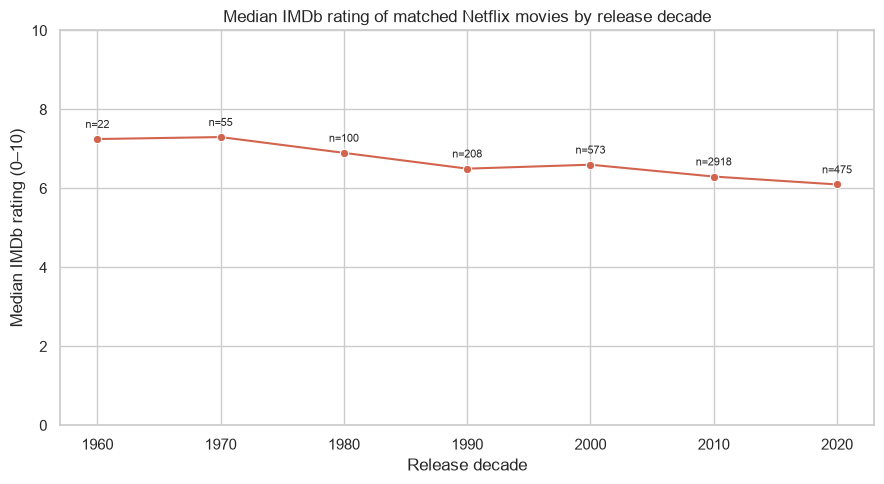

,release_decade,median_rating,titles
0,1960,7.25,22
1,1970,7.30,55
2,1980,6.90,100
3,1990,6.50,208
4,2000,6.60,573
5,2010,6.30,2918
6,2020,6.10,475


In [14]:
year_rating = (
    analysis.drop_duplicates("show_id")
    .assign(release_decade=lambda frame: (frame["release_year"] // 10 * 10).astype(int))
    .groupby("release_decade")
    .agg(median_rating=("imdb_rating", "median"), titles=("show_id", "size"))
    .query("titles >= 20")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=year_rating, x="release_decade", y="median_rating", marker="o", color="#d2644e", ax=ax)
ax.set(title="Median IMDb rating of matched Netflix movies by release decade", xlabel="Release decade", ylabel="Median IMDb rating (0–10)", ylim=(0, 10))
for row in year_rating.itertuples():
    ax.annotate(f"n={row.titles}", (row.release_decade, row.median_rating), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)
plt.tight_layout()
plt.show()
year_rating

The matched catalog's older movie cohorts generally have higher median ratings than its most recent cohorts. This may reflect survivorship and selection—older films that remain licensed are not a random sample of all older releases—so it should not be interpreted as evidence that movie quality declined.

### 5.2 Reflection

With more time, I would evaluate fuzzy-title matches manually and add alternate identifiers to estimate how many valid joins the exact rule misses. I would also normalize multi-country values into a separate title–country table and compare the snapshot with later Netflix catalogs to distinguish release-era patterns from catalog selection.